# DECIPHER Summer School 2025, Bilbao

## DIVACoast.jl

### What is DIVACoast.jl? 

`DIVACoast.jl` is a package for the programming language Julia. The package is currently under development and designed to provide a broad toolset for **coastal risk & adapatation assessment**. The key concept of `DIVACoast.jl` is the concept of risk. Following the definition of the Intergovernmental Panel on Climate Change (IPCC), risk constituted by the three components of hazard, exposure and vulnerability (Oppenheimer et al., 2019; Wong et al., 2014). While on the long run the package is meant to serve multiple coastal risks including the risk of flooding, erosion, salinity intrusion and wetland change, the current release concentrates on flood risk.

### What will you learn in this session?
1. How to use `DIVACoast.jl`
2. Flood Exposure assessment
    - `HypsometricProfiles`:
        - load HypsometricProfiles
        - calculate exposure using `HypsometricProfiles`
        - modify exposure
3. Flood Damage calculation
    - Damages using different Inundation Models
    - Damages using different damage functions
4. Flood adaptation
    - Protection
    - Retreat 
    - Land Raising
    - Nature based solutions by attenuation

### How to use `DIVACoast.jl`

On Google Colab

In [ ]:
using Pkg
Pkg.add(url = "https://github.com/GlobalClimateForum/DIVACoast.jl")
using .DIVACoast

Local
1. Clone DIVACoast.jl to your local machine by: 
```git
git clone https://github.com/GlobalClimateForum/DIVACoast.jl.git
```
2. Include DIVACoast.jl in your scirpt:

In [1]:
using Pkg
Pkg.activate("../.") # Path to DIVACoast.jl folder
include("../src/DIVACoast.jl") # Include the library
using .DIVACoast # Add the local library to the namespace

  Activating project at `~/DIVA/DIVACoast`


┌                                       ┐


┌ Warning: Replacing docs for `Main.DIVACoast.damage_bathtub_standard_ddf :: Union{Tuple{DT}, Tuple{Main.DIVACoast.HypsometricProfile{DT}, DT, DT, Array{DT}}} where DT<:Real` in module `Main.DIVACoast`
└ @ Base.Docs docs/Docs.jl:243


│ DIVACoast.jl | © GLOBAL CLIMATE FORUM │
└                                       ┘


Load Packages

In [2]:
using Plots
using DataFrames

## Exposure assessment

### What is a HypsometricProfile?
Currently the main way to represent exposure in DIVACoast.jl is as `HypsometricProfile`. This is a special kind of coastal profile that allows for a very efficient computation of flood damages, which is beneficial for running large number of damage assessments as, e.g., required for many economic questions that involve optimization.

### HypsometricProfiles

For this example we pre-calculated `HypsometricProfiles` around Europe. You can load them using:

In [3]:
testdata    = "../testdata/hpfs_europe.jld2"
hypsometric_profiles = load(testdata, Dict{Int32, HypsometricProfile{Float32}}) |> HypsometricProfileCollection

┌ Info: Loaded Dict{Int32, HypsometricProfile{Float32}} created at 2025-07-01T19:01:49.500
└ @ Main.DIVACoast /home/honsel/DIVA/DIVACoast/src/io/jld/jld_load.jl:70


┌ HypsometricProfileCollection
└ Number of HypsometricProfiles: 19547



Lets also define a Hypsometric Profile of interest. You can get the ID for your region of interest by using this [map](https://globalclimateforum.github.io/DIVACoastExplorer/). Note that the outlines in the map are simplified for visualization purpose and not represent the real outlines accurately.

In [110]:
hp_roi = hypsometric_profiles["73655"] # Small floodplain in Santander, Spain

┌ HypsometricProfile
├ Width: 12.093767 km
├ Elevation: -5.0 up to 20.0m at 251 increments
├ Cum. area (maximum): 13.778824km^2
└ Exposures:
  ├ population: 251 values from 0.0 to 42841.21
  ├ assets: 251 values from 0.0 to 4.1852221e9

... and plot it.

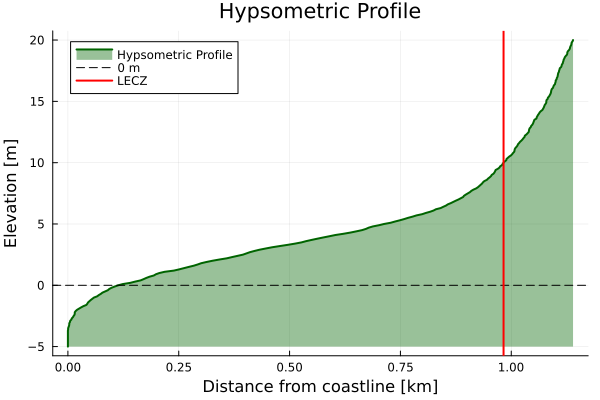

In [5]:
plot(hp_roi)

to inspect the values you can convert the `HypsometricProfile` to a `DataFrame`:

In [6]:
hp_roi_df = DataFrame(hp_roi)

Row,elevation,cumulativeArea,width,population,assets
,Float32,Float32,Float32,Float32,Float32
1,-5.0,0.0,12.0938,0.0,0.0
2,-4.9,0.0,12.0938,0.0,0.0
3,-4.8,0.0,12.0938,0.0,0.0
4,-4.7,0.0,12.0938,0.0,0.0
5,-4.6,0.0,12.0938,0.0,0.0
6,-4.5,0.0,12.0938,0.0,0.0
7,-4.4,0.0,12.0938,0.0,0.0
8,-4.3,0.0,12.0938,0.0,0.0
9,-4.2,0.0,12.0938,0.0,0.0


### Exposure

The `exposure()` function is used to calculate the cumulative exposure below given water level (`wl`) for a hypsometric profile and for all exposure variables in a `HypsometricProfile` given a `InundationModel` (default is bathtub inundation). 

Arguments are:
- `hspf::HypsometricProfile{DT}`: The hypsometric profile with elevation, area and exposure data.
- `wl::Real`: The water level for which exposure is calculated.
- `s::String or s::Symbol or s::Array{String} or Array{Symbol}`: An array of exposure variable names for which the damage is calculated. If only one variable is used please use the version with a single variable instaed of an array (the latter one might cause problems then).
- `im::IM`: the inundation model used to calculate the propagation of the water level.


#### Excercise 1

Use the `exposure()` function to calculate exposed assets and population under different flood scenarios: 1m, 2m , 3m ...for your floodplain of interest.

In [98]:
waterlevel_scenarios = 1:0.1:5 |> Vector{Float32}

exposures = map(wl -> wl => exposure(hp_roi, wl), waterlevel_scenarios)
exposures = map(wl -> wl => named(exposure, (hp_roi, wl)), waterlevel_scenarios) # To get named exposures


41-element Vector{Pair{Float32, @NamedTuple{cumulativeArea::Float32, population::Float32, assets::Float32}}}:
 1.0 => (cumulativeArea = 2.494139, population = 2798.766, assets = 2.5047091f8)
 1.1 => (cumulativeArea = 2.637558, population = 2920.9631, assets = 2.6140672f8)
 1.2 => (cumulativeArea = 2.893199, population = 3411.0789, assets = 3.0526883f8)
 1.3 => (cumulativeArea = 3.0366125, population = 3646.3174, assets = 3.263211f8)
 1.4 => (cumulativeArea = 3.1675558, population = 3754.3198, assets = 3.3598662f8)
 1.5 => (cumulativeArea = 3.2985003, population = 4031.8542, assets = 3.608241f8)
 1.6 => (cumulativeArea = 3.435677, population = 4360.8633, assets = 3.9026822f8)
 1.7 => (cumulativeArea = 3.5416732, population = 4728.753, assets = 4.2319194f8)
 1.8 => (cumulativeArea = 3.6352, population = 4908.7324, assets = 4.3929888f8)
 1.9 => (cumulativeArea = 3.7786014, population = 5214.6475, assets = 4.6667622f8)
     ⋮
 4.2 => (cumulativeArea = 7.51324, population = 16013.974, asset

To modify the exposure in a `HypsometricProfile` you can use the [HypsometricProfile modifiers](https://globalclimateforum.github.io/DIVACoast.jl/exposure.html#Modifying-Hypsometric-Profiles) provided by `DIVACoast.jl`.
Lets assume we have a population decline in our profile by factor 0.85 above 5m and a population increase by factor 1.1 below 5m. You can simulate this scenario by:

In [ ]:
multiply_exposure_above!(hp_roi, 5.0, :population,  0.85) # Applies a factor of 0.85 to population above 5m elevation
multiply_exposure_below!(hp_roi, 5.0, :population, 1.1) # Applies a factor of 1.1 to population below 5m elevation

Let's check by calculating the exposure again:

In [117]:
waterlevel_scenarios = 1:1:10 |> Vector{Float32}
map(wl -> wl => named(exposure, (hp_roi, wl)), scenarios)

10-element Vector{Pair{Float32, @NamedTuple{cumulativeArea::Float32, population::Float32, assets::Float32}}}:
  1.0 => (cumulativeArea = 2.494139, population = 3078.6428, assets = 2.5047091f8)
  2.0 => (cumulativeArea = 3.9407058, population = 6328.559, assets = 5.1487626f8)
  3.0 => (cumulativeArea = 5.393466, population = 10086.427, assets = 8.206072f8)
  4.0 => (cumulativeArea = 7.132933, population = 16114.201, assets = 1.3110124f9)
  5.0 => (cumulativeArea = 8.622937, population = 22662.453, assets = 1.8437623f9)
  6.0 => (cumulativeArea = 9.882311, population = 26442.652, assets = 2.3120015f9)
  7.0 => (cumulativeArea = 10.655366, population = 29397.865, assets = 2.6780524f9)
  8.0 => (cumulativeArea = 11.185289, population = 31422.768, assets = 2.9288694f9)
  9.0 => (cumulativeArea = 11.559347, population = 33177.742, assets = 3.1462505f9)
 10.0 => (cumulativeArea = 11.883533, population = 34734.9, assets = 3.3391288f9)

#### Excercise 2

Simulate the following scenarios, subdividing changes for population and assets above and below 5m elevation:

| year | pop. change <5m | pop. change ≥5m | asset change <5m | asset change ≥5m |
| ---- | --------------- | --------------- | ---------------- | ---------------- |
| 2025 | 1.00            | 1.00            | 1.00             | 1.00             |
| 2030 | 0.98            | 0.98            | 1.02             | 1.00             |
| 2035 | 0.96            | 0.96            | 1.04             | 1.01             |
| 2040 | 0.94            | 0.94            | 1.06             | 1.02             |
| 2045 | 0.92            | 0.92            | 1.08             | 1.03             |
| 2050 | 0.90            | 0.90            | 1.10             | 1.04             |

## Damage calculation

[INTRODUCTION_TEXT]

- Using different `InundationModels`
- Using different damage funcitons
    - plot functions
    - apply to hypsometricprofiles

## Adaptation
- Protection? 
- Retreat
    - using exposure modifiers? 
- Land Raising
- NBS using attenuation

## Additional